In [1]:
from google.colab import files
uploaded = files.upload()

Saving black horse.jpg to black horse.jpg


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
img = Image.open("black horse.jpg").convert("L")
img = np.array(img)

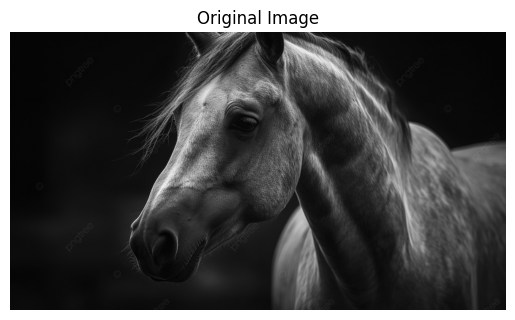

In [5]:
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [6]:
hist = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i,j]] += 1

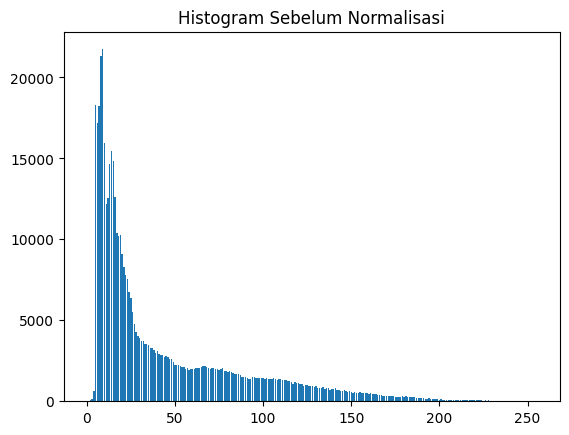

In [7]:
plt.title("Histogram Sebelum Normalisasi")
plt.bar(range(256), hist)
plt.show()

In [8]:
total_pixels = img.shape[0] * img.shape[1]

hist_norm = np.zeros(256)

for i in range(256):
    hist_norm[i] = hist[i] / total_pixels

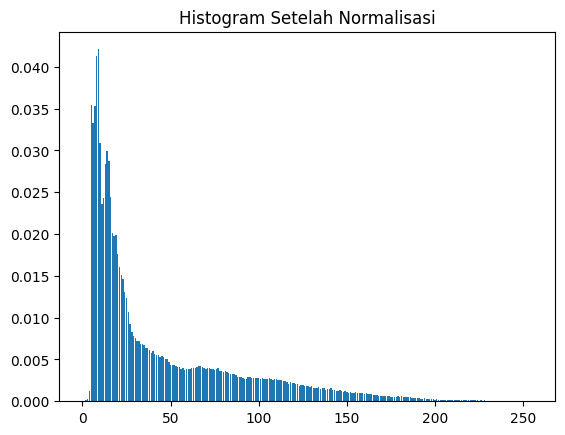

In [9]:
plt.title("Histogram Setelah Normalisasi")
plt.bar(range(256), hist_norm)
plt.show()

In [10]:
cdf = np.zeros(256)
cdf[0] = hist_norm[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist_norm[i]

In [11]:
equalized = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized[i,j] = int(255 * cdf[img[i,j]])

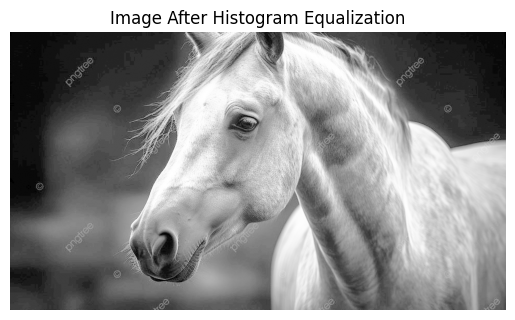

In [12]:
plt.imshow(equalized, cmap='gray')
plt.title("Image After Histogram Equalization")
plt.axis('off')
plt.show()

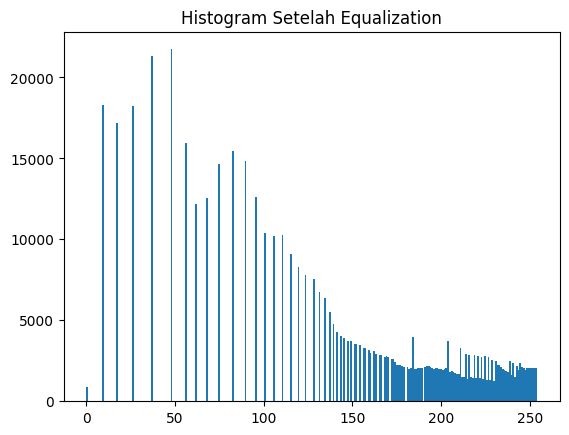

In [13]:
plt.title("Histogram Setelah Equalization")
plt.hist(equalized.flatten(), bins=256)
plt.show()